In [1]:
import torch
import math
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
torch.set_default_dtype(torch.float64)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
I2 = torch.eye(2, dtype=torch.complex128, device=device)
X  = torch.tensor([[0, 1], [1, 0]], dtype=torch.complex128, device=device)
Y  = torch.tensor([[0, -1j], [1j, 0]], dtype=torch.complex128, device=device)
Z  = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128, device=device)


In [4]:
def channel(rho, px, py):
    # px, py are python floats or torch scalars
    px_t = torch.as_tensor(px, dtype=torch.float64, device=device)
    py_t = torch.as_tensor(py, dtype=torch.float64, device=device)

    # ensure valid probs (for safety)
    p0 = torch.clamp(1.0 - px_t - py_t, min=0.0)

    kraus = [
        torch.sqrt(p0).to(torch.complex128) * I2,
        torch.sqrt(px_t).to(torch.complex128) * X,
        torch.sqrt(py_t).to(torch.complex128) * Y,
    ]

    out = torch.zeros_like(rho)
    for K1 in kraus:
        for K2 in kraus:
            op = torch.kron(K1, K2)  # 4x4
            out = out + op @ rho @ op.conj().T
    return out


def trace_norm_hermitian(H):
    # For Hermitian H: ||H||_1 = sum |eigs|
    evals = torch.linalg.eigvalsh(H)
    return torch.sum(torch.abs(evals))


def density_matrix(psi):
    return psi[:, None] @ psi.conj()[None, :]

def softplus_unit_sphere(u, eps=1e-12):
    """
    u: real tensor of shape (4,)
    returns: tensor (4,) with sum of squares = 1 and all entries > 0
    """
    v = F.softplus(u)                  # v_i > 0
    norm = torch.sqrt(torch.sum(v*v).clamp(min=eps))
    return v / norm

# ----------------------------
# Your objective, but made safe & differentiable
# We optimize over an unconstrained raw vector in R^11
# and map it to your param format:
# [a1,a2,theta2,a3,theta3,b1,phi1,b2,phi2,b3,phi3]
# ----------------------------



def objective_from_raw(raw, px=0.3, py=0.2, eps=1e-12):
    """
    raw: torch.float64 tensor shape (13,) unconstrained
    returns: scalar real tensor to maximize
    """

    # amplitudes in (0,1)
    # indices: a0=11,a1=0,a2=1,a3=3,b0=12,b1=5,b2=7,b3=9
    sig = torch.sigmoid


    # angles in [0, 2π)
    twopi = 2.0 * math.pi
    theta2 = twopi * sig(raw[2])
    theta3 = twopi * sig(raw[4])

    phi1   = twopi * sig(raw[6])
    phi2   = twopi * sig(raw[8])
    phi3   = twopi * sig(raw[10])

    # a0, b0 with clamping to avoid sqrt of negative
    # ---- amplitudes for psi ----
    u_psi = raw[[11,0,1,3]]  # pick 4 real params
    a0, a1, a2, a3 = softplus_unit_sphere(u_psi)

    # ---- amplitudes for phi ----
    u_phi = raw[[12,5,7,9]]  # pick 4 real params
    b0, b1, b2, b3 = softplus_unit_sphere(u_phi)
    # compute theta1 from your constraint (with eps to avoid division by 0)
    denom = a1 * b1
    denom = torch.clamp(denom, min=eps)

    # complex expression inside log
    # NOTE: keep everything as complex here
    num = (
        a0 * b0
        + a2 * b2 * torch.exp(1j * (theta2 - phi2))
        + a3 * b3 * torch.exp(1j * (theta3 - phi3))
    )
    z = -(num / denom)  # complex

    theta1 = phi1 + torch.atan2( torch.imag(z)  , torch.real(z) ) # complex

    # build psi, phi in C^4
    psi = torch.zeros(4, dtype=torch.complex128, device=device)
    psi[0] = a0.to(torch.complex128)
    psi[1] = a1.to(torch.complex128) * torch.exp(1j * theta1)
    psi[2] = a2.to(torch.complex128) * torch.exp(1j * theta2)
    psi[3] = a3.to(torch.complex128) * torch.exp(1j * theta3)

    phi = torch.zeros(4, dtype=torch.complex128, device=device)
    phi[0] = b0.to(torch.complex128)
    phi[1] = b1.to(torch.complex128) * torch.exp(1j * phi1)
    phi[2] = b2.to(torch.complex128) * torch.exp(1j * phi2)
    phi[3] = b3.to(torch.complex128) * torch.exp(1j * phi3)

    delta = density_matrix(psi) - density_matrix(phi)  # 4x4 Hermitian
    H = channel(delta, px=px, py=py)




    return 0.5 * trace_norm_hermitian(H)


# ----------------------------
# Optimizer runner (maximization via minimizing -objective)
# ----------------------------
def maximize(px=0.3, py=0.2, steps=4000, lr=2e-2, restarts=10, seed=0, print_every=400):
    torch.manual_seed(seed)

    best_val = -float("inf")
    best_raw = None

    for r in range(restarts):
        raw = (0.1 * torch.randn(13, device=device)).requires_grad_(True)
        opt = torch.optim.Adam([raw], lr=lr)

        for t in range(steps):
            opt.zero_grad()
            f = objective_from_raw(raw, px=px, py=py)
            loss = -f
            loss.backward()
            opt.step()

            #if (t + 1) % print_every == 0:
            #    print(f"[restart {r+1}/{restarts}] step {t+1:5d} | f = {f.item():.12f}")

        final_f = objective_from_raw(raw, px=px, py=py).detach().item()
        if final_f > best_val:
            best_val = final_f
            best_raw = raw.detach().clone()

    return best_raw, best_val

def optimal_value(px,py):
    return max(abs(1-2*px),abs(1-2*py), abs(1-2*px-2*py))

In [5]:
lr = 2e-3
seed = 10
epsilon = 1e-12

px_min = epsilon
py_min = epsilon
px_max = 1-epsilon

size = 5
steps = 1000
restarts = 3



In [6]:
best_raw_list = []
best_val_list = []

for px in np.linspace(px_min, px_max, size):
    for py in np.linspace(px_min, 1-px, size):
        opt = optimal_value(px,py)
        best_raw, best_val = maximize(px,py,steps,lr, restarts,seed )
        best_raw_list.append(best_raw)
        best_val_list.append(best_val)
        #print("\npx value:", px)
        #print("\npy value:", py)
        #print("\nOptimal value:", opt)
        #print("\nBest value found:", best_val)
        #print("Best raw parameters:", best_raw.cpu().numpy())
        #print("\nDifference in values:", best_val - opt)

In [7]:
arr = []
k = 0

px_list = []
py_list = []

for px in np.linspace(px_min, px_max, size):
    for py in np.linspace(py_min, 1-px, size):
        px_list.append(px)
        py_list.append(py)
        opt = optimal_value(px,py)
        best_val = best_val_list[k]

        arr.append(best_val-opt)

        k += 1

px_arr = np.array(px_list)
py_arr = np.array(py_list)
arr = np.array(arr)

mean = np.mean(arr)
mag = np.abs(arr)
mean_mag = np.mean(mag)
rms = np.sqrt(np.mean(arr**2))

print(mean, mean_mag, rms)



-0.011613017866716062 0.011613017866716062 0.01928031310194269


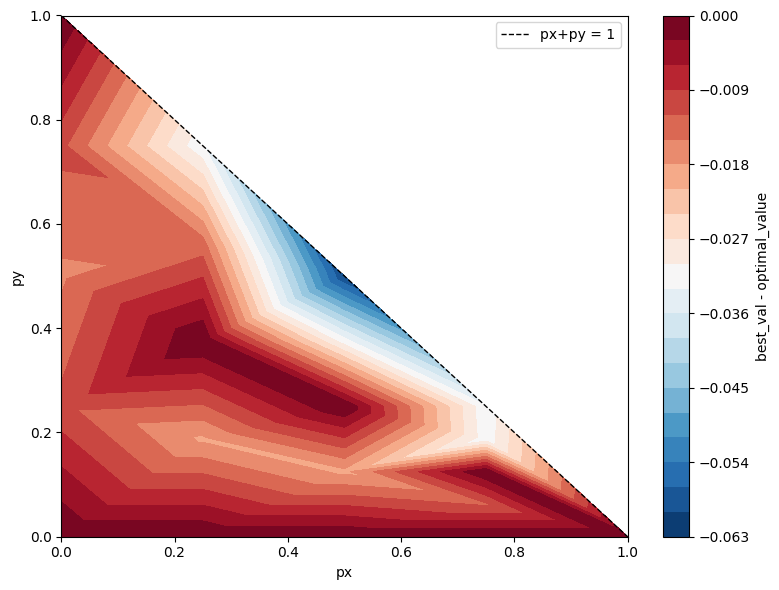

In [8]:
fig, ax = plt.subplots(figsize = (8,6))
tcf = ax.tricontourf(px_arr,py_arr,arr,levels = 20, cmap = 'RdBu_r')
fig.colorbar(tcf, ax= ax, label = 'best_val - optimal_value')
ax.set_xlabel('px')
ax.set_ylabel('py')

px_line= np.linspace(0,1,100)
ax.plot(px_line, 1-px_line, 'k--', lw= 1, label = 'px+py = 1')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
print(max(mag))
idx = np.argmax(mag)
print(idx)
print(px_arr[idx])
print(py_arr[idx])

0.06017696850344345
14
0.5
0.5


Find the index of this and the px and py that gives this value and just increase steps for this if this get any better.

Check if increasing steps would increase the precision

In [12]:
#Pick from above the most varying value and use its settings

px = px_arr[idx]-0.1
py = py_arr[idx]-0.1

step_list = [1000,2000,4000,10000,20000]
step_ave_list = []
seed_list = [2,3,4,5];
for n_steps in step_list:
    ave = 0
    for seed in seed_list:
        opt = optimal_value(px,py)
        best_raw, best_val = maximize(px,py,n_steps,lr, 1,seed )

        result = opt-best_val
        print(f"For step: {n_steps} and seed: {seed} result calculated")

        ave += result

    ave = ave / len(seed_list)
    step_ave_list.append(ave)
    print(f"For step : {n_steps}, average difference is : {ave}")






For step: 1000 and seed: 2 result calculated
For step: 1000 and seed: 3 result calculated
For step: 1000 and seed: 4 result calculated
For step: 1000 and seed: 5 result calculated
For step : 1000, average difference is : 0.0821048652806674
For step: 2000 and seed: 2 result calculated
For step: 2000 and seed: 3 result calculated
For step: 2000 and seed: 4 result calculated
For step: 2000 and seed: 5 result calculated
For step : 2000, average difference is : 0.008780298724204633
For step: 4000 and seed: 2 result calculated
For step: 4000 and seed: 3 result calculated
For step: 4000 and seed: 4 result calculated
For step: 4000 and seed: 5 result calculated
For step : 4000, average difference is : 0.001784465555327075
For step: 10000 and seed: 2 result calculated
For step: 10000 and seed: 3 result calculated
For step: 10000 and seed: 4 result calculated
For step: 10000 and seed: 5 result calculated
For step : 10000, average difference is : 7.203245994910623e-05
For step: 20000 and seed: 2 

In [16]:

seed_list = [11];
for n_steps in [100000,200000]:
    ave = 0
    for seed in seed_list:
        opt = optimal_value(px,py)
        best_raw, best_val = maximize(px,py,n_steps,lr, 1,seed )

        result = opt-best_val
        print(f"For step: {n_steps} and seed: {seed} result calculated")

        ave += result

    ave = ave / len(seed_list)
    step_ave_list.append(ave)
    print(f"For step : {n_steps}, average difference is : {ave}")



For step: 100000 and seed: 11 result calculated
For step : 100000, average difference is : 7.013423175550315e-11
For step: 200000 and seed: 11 result calculated
For step : 200000, average difference is : 2.8568925003469303e-11


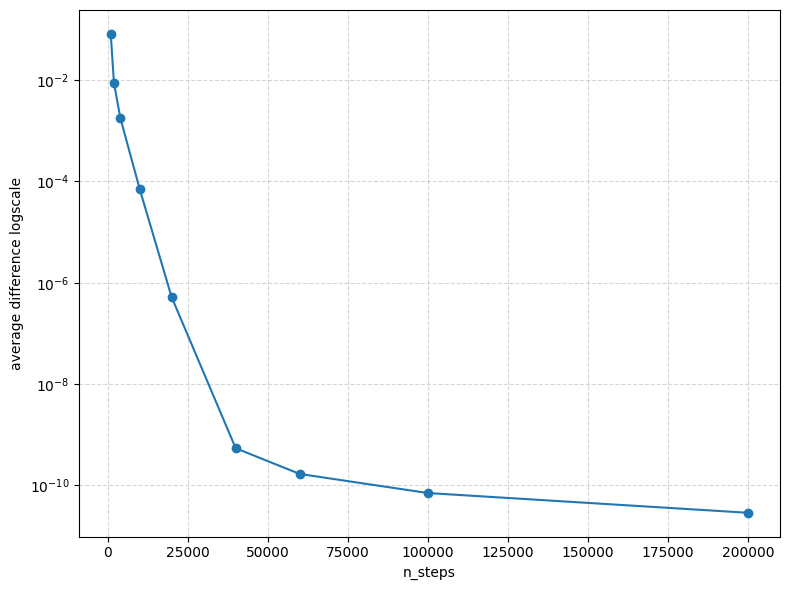

In [18]:
all_steps = [1000,2000,4000, 10000,20000,40000,60000, 100000,200000]
fig,ax = plt.subplots(figsize = (8,6))
ax.semilogy(all_steps, step_ave_list, 'o-')
ax.set_xlabel("n_steps")
ax.set_ylabel("average difference logscale")
ax.grid(True, which = 'both', linestyle = '--', alpha = 0.5)
plt.tight_layout()

plt.savefig('average_difference.png')
plt.show()